# Q1
# PyMC Example Gallery Contents

## Introductory

- [Bayesian Regression with Truncated or Censored Data](https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/GLM-truncated-censored-regression.html)
- [GLM: Robust Linear Regression](https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/GLM-robust.html)
- [Hierarchical Binomial Model: Rat Tumor Example](https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/GLM-hierarchical-binomial-model.html)

<table>
  <tr>
    <td><img src="https://www.pymc.io/projects/examples/en/latest/_images/833e85c397967de588409136ca9a0f916f3c8fe280acfe1897c235914af7a2be.png" width="300"></td>
    <td><img src="https://www.pymc.io/projects/examples/en/latest/_images/2a78b97583ee869cae0dd0c05e5342683605d657e6baf4e1169a55644bddf662.png" width="300"></td>
    <td><img src="https://www.pymc.io/projects/examples/en/latest/_images/5c1c9556b40edd58d8f6b25f1716c8a2d461b3d2407e4c264d23c211f3c74c4d.png" width="300"></td>
  </tr>
</table>

## Library Fundamentals

- Understanding Probability Structures

  Explore how PyMC handles probability distributions of different dimensions, including one-dimensional, two-dimensional, and higher-dimensional models.

- Computational Acceleration with PyTensor

  Learn how PyMC leverages PyTensor to optimize computations, improve posterior inference efficiency, and enable automatic differentiation.

- Efficient Data Management in Bayesian Models

  Understand how to structure, store, and efficiently load data in PyMC for Bayesian modeling, improving inference workflows.

In [1]:
!pip install pymc

In [3]:
import pymc as pm
print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.20.0


Output()

Output()

Output()

Output()

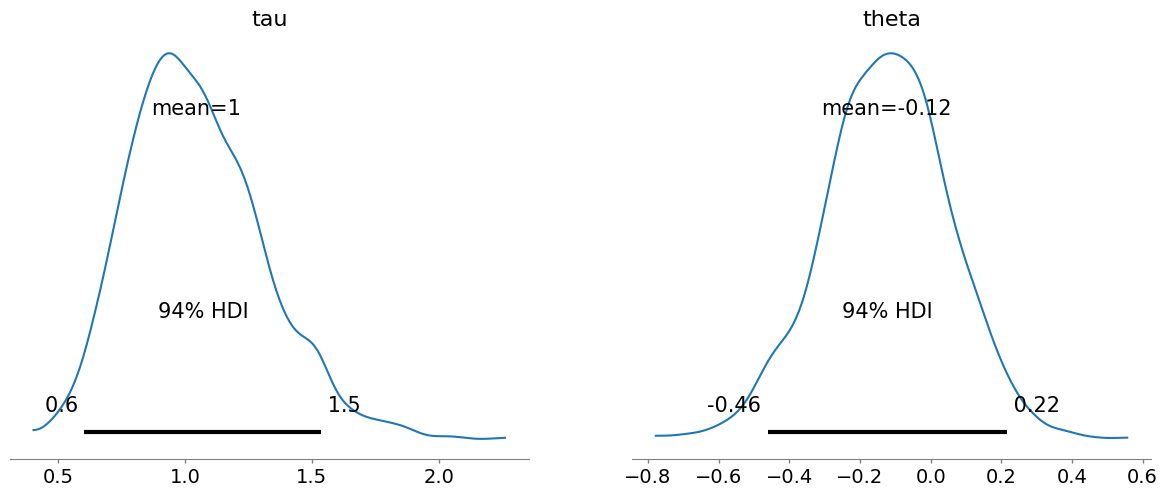

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
tau    1.046  0.264   0.604    1.537      0.007    0.005    1469.0    1302.0   
theta -0.124  0.180  -0.462    0.216      0.004    0.004    1933.0    1505.0   

       r_hat  
tau      1.0  
theta    1.0  


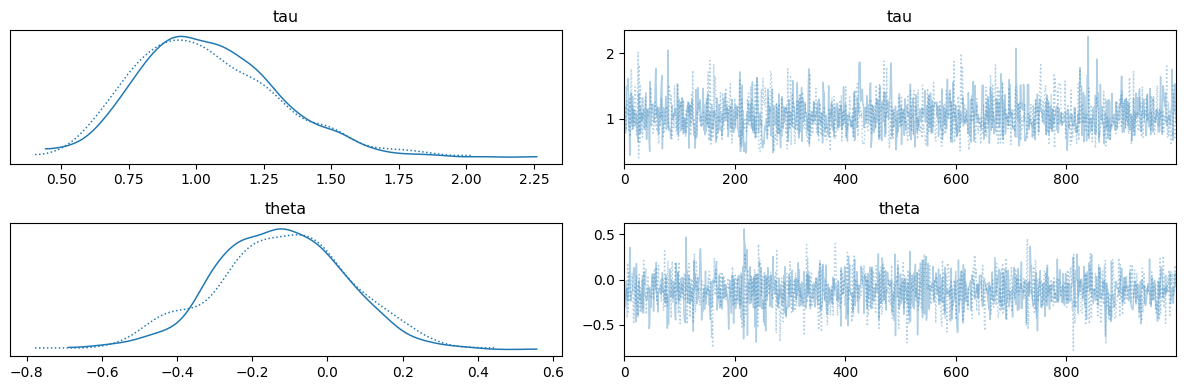

In [8]:
#Q2
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# Generate synthetic data
n = 30
x = np.random.normal(loc=0, scale=1, size=n)

# 1. Define a Bayesian model where theta follows a normal prior and tau follows a gamma prior
with pm.Model() as model1:
    theta = pm.Normal('theta', mu=0, sigma=1)
    tau = pm.Gamma('tau', alpha=2, beta=1)
    x_obs = pm.Normal('x_obs', mu=theta, tau=tau, observed=x)
    idata1 = pm.sample(1000, chains=2, return_inferencedata=True)
# Perform MCMC sampling
    idata1 = pm.sample(1000, chains=2, return_inferencedata=True)

az.plot_posterior(idata1, hdi_prob=0.94)
plt.show()


# Assess sampling diagnostics
az.plot_trace(idata1)
plt.tight_layout()
print(az.summary(idata1))

Output()

Output()

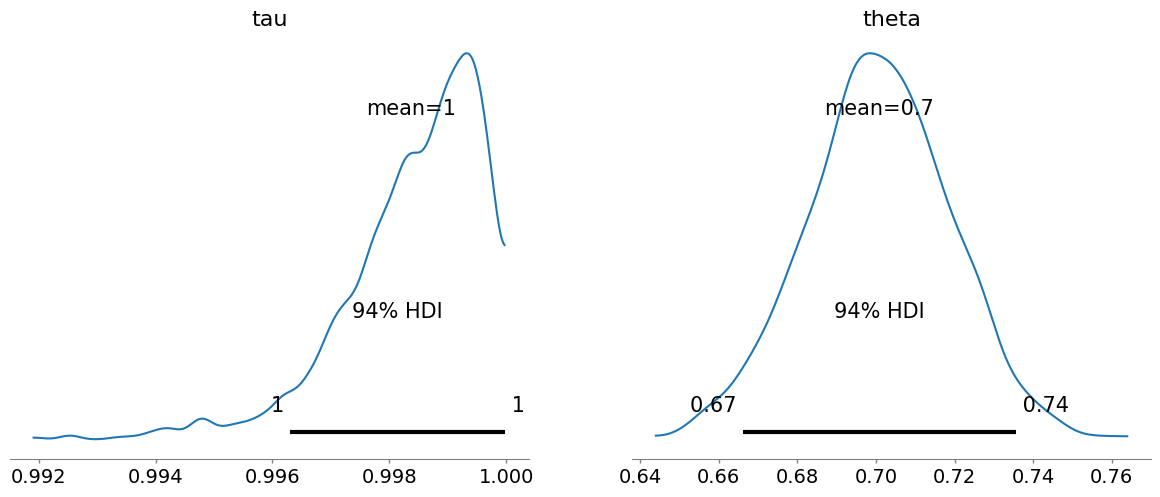

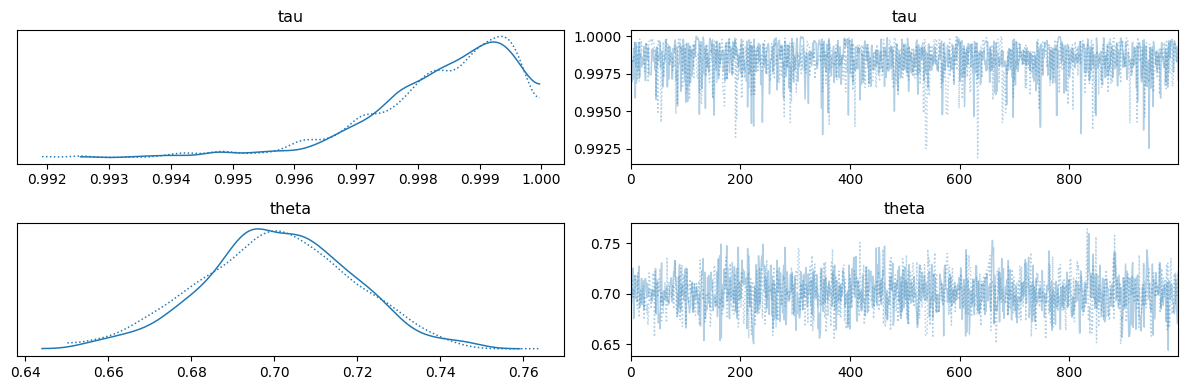

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
tau    0.998  0.001   0.996    1.000        0.0      0.0    1379.0    1066.0   
theta  0.701  0.018   0.666    0.736        0.0      0.0    1477.0    1298.0   

       r_hat  
tau      1.0  
theta    1.0  


In [21]:
# Define the Bayesian model with Uniform and Beta priors
with pm.Model() as model2:
    theta = pm.Uniform('theta', lower=-5, upper=5)  # Uniform prior for theta
    tau = pm.Beta('tau', alpha=2, beta=2)  # Beta prior for tau (constrained between 0 and 1)
    x_obs = pm.Normal('x_obs', mu=theta, tau=tau, observed=x)
    idata2 = pm.sample(1000, chains=2, return_inferencedata=True)

# Posterior distribution plots
az.plot_posterior(idata2, hdi_prob=0.94)
plt.show()

# Trace plot for diagnostics
az.plot_trace(idata2)
plt.tight_layout()
plt.show()

# Summary statistics
print(az.summary(idata2))


Output()

Output()

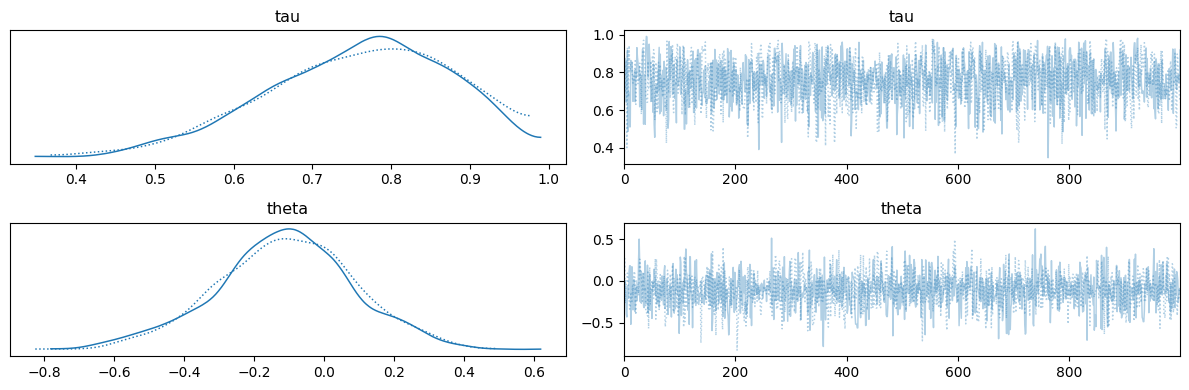

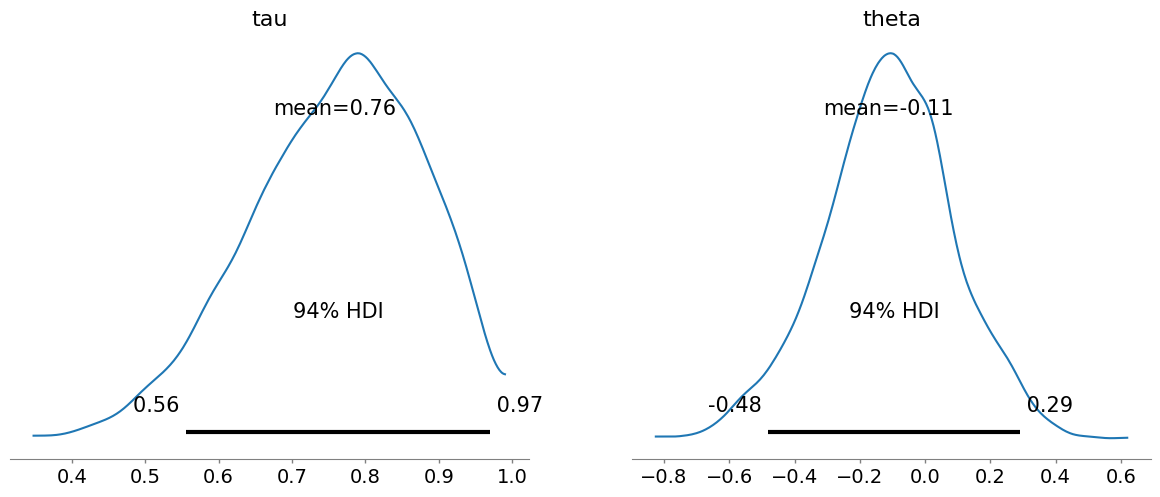

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
tau    0.758  0.117   0.556    0.969      0.003    0.002    1642.0    1473.0   
theta -0.112  0.201  -0.480    0.290      0.005    0.004    1704.0    1159.0   

       r_hat  
tau      1.0  
theta    1.0  


In [17]:
# 3. Bayesian estimation with alternative non-Normal and non-Gamma priors
with pm.Model() as model3:
    theta = pm.Laplace('theta', mu=0, b=1)  # Prior for theta follows a Laplace distribution
    tau = pm.Beta('tau', alpha=2, beta=2)   # Prior for tau follows a Beta distribution
    x_obs = pm.Normal('x_obs', mu=theta, tau=tau, observed=x)  # Likelihood function
    idata3 = pm.sample(1000, chains=2, return_inferencedata=True)  # Sampling from posterior

# Visualizing the posterior distributions and sampling diagnostics
az.plot_trace(idata3)
plt.tight_layout()

az.plot_posterior(idata3, hdi_prob=0.94)
plt.show()


# Displaying key summary statistics
print(az.summary(idata3))


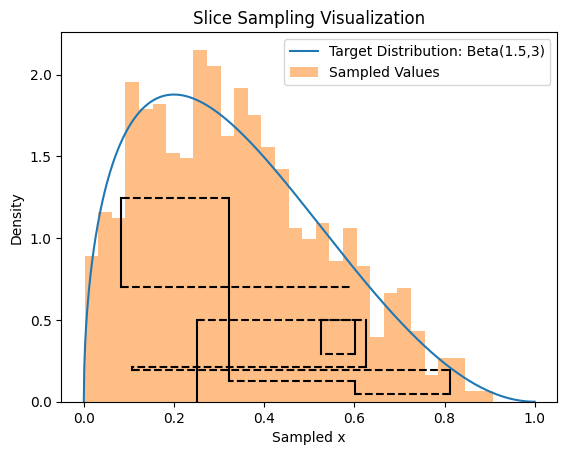

In [19]:
#Q3
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
# Function to perform slice sampling
def slice_sample(f, x, y, x_grid=np.linspace(0,1,51)):
    """
    Implements slice sampling by identifying an interval where f(x) > y
    and selecting a new x within that interval.
    """
    x_grid_delta = x_grid[1] - x_grid[0]
    a, b = x_grid[f(x_grid) > y][[0, -1]] + [-x_grid_delta, x_grid_delta]

    x_ = a + stats.uniform().rvs() * (b - a)
    if f(x_) > y:
        return x_, 1
    elif x_ < x:
        x_l, x_r = x_, b
    else:
        x_l, x_r = a, x_
    return refine_sample(f, x, y, x_l, x_r, attempts=2)

def refine_sample(f, x, y, x_l=0, x_r=1, attempts=1):
    """
    Recursively refines the slice sampling process to ensure x remains
    within the valid probability region.
    """
    x_ = x_l + stats.uniform().rvs() * (x_r - x_l)
    if f(x_) > y:
        return x_, attempts
    elif x_ < x:
        x_l = x_
    else:
        x_r = x_
    return refine_sample(f, x, y, x_l, x_r, attempts + 1)
# Define the target distribution
x_grid = np.linspace(0, 1, 1000)
f = lambda x: stats.beta(1.5, 3).pdf(x)

# Initialize slice sampling
samples = 1000
x = np.zeros([samples + 1, 3])
x[:2, 0] = 0.25

plot_steps = 10
for t in range(1, samples):
    x[t, 1] = stats.uniform().rvs() * f(x[t, 0])  # Randomly pick threshold y
    if t < plot_steps:
        plt.plot([x[t, 0]] * 2, [x[t - 1, 1], x[t, 1]], 'k')

    x[t + 1, 0], x[t + 1, 2] = slice_sample(f, x[t, 0], x[t, 1])
    if t < plot_steps:
        plt.plot([x[t, 0], x[t + 1, 0]], [x[t, 1]] * 2, 'k--')

# Plot results
plt.plot(x_grid, f(x_grid), label="Target Distribution: Beta(1.5,3)")
plt.hist(x[:, 0], density=True, bins=30, alpha=0.5, label="Sampled Values")
plt.legend()
plt.xlabel("Sampled x")
plt.ylabel("Density")
plt.title("Slice Sampling Visualization")
plt.show()



# Q3: Slice Sampling

## 1. Overview of the Slice Sampling Algorithm

Slice sampling is a Markov Chain Monte Carlo (MCMC) method used to sample from complex distributions when the normalization constant is unknown. The core idea is to introduce an auxiliary variable and sample uniformly from the region under the probability density function (PDF), effectively "slicing" the function.

### Steps in the Algorithm:
1. **Define the Target Function**: The function \( f(x) \) represents the probability distribution we aim to sample from.
2. **Initialize a Starting Point**: Choose an initial value \( x \).
3. **Vertical Sampling**: Draw a vertical coordinate \( y \) uniformly from the range \( [0, f(x)] \). This defines a horizontal slice.
4. **Horizontal Sampling**: Select a new candidate \( x' \) uniformly from the region where \( f(x') > y \).
5. **Acceptance Criteria**: If \( f(x') > y \), accept \( x' \) as the new sample. If not, reduce the interval and retry.

This process is repeated iteratively, adjusting the sampling region until a suitable \( x' \) is found.

---

## 2. Replacing Metropolis-Hastings in Gibbs Sampling

Slice sampling can serve as an alternative to the Metropolis-Hastings step in a Gibbs sampler when full conditional distributions are only known up to a normalizing constant.

### How Slice Sampling Works in a Gibbs Sampler:
- **Sampling from Full Conditionals**: Unlike Metropolis-Hastings, which proposes a new state and accepts/rejects it, slice sampling directly samples from a defined slice.
- **Defining the Slice**: The function being sampled is the unnormalized full conditional density.
- **Initialization**: The current state of the Markov chain is used as the starting point.
- **Sampling Process**:
  1. Sample \( y \) uniformly from \( 0, $f(x_{\text{current}})$) \.
  2. Determine the slice: the interval where \( f(x) > y \).
  3. Draw a new sample \( x' \) uniformly from the slice.
  4. Repeat for each variable in the Gibbs cycle.

Using slice sampling in a Gibbs framework avoids the need for proposal distributions and often improves mixing for complex distributions.

---

## 3. Explanation of the Sampling Process

### **Key Steps in Slice Sampling**
1. **Selecting an Initial Value**: Choose an initial point \( x \) within the target distribution.
2. **Drawing a Vertical Slice**: A uniform value \( y \) is sampled from the interval \( [0, f(x)] \), defining a slice within which \( x' \) must be located.
3. **Sampling Within the Slice**: A new candidate \( x' \) is drawn uniformly from the region where \( f(x') > y \).
4. **Shrinking the Interval**: If the proposed \( x' \) does not satisfy the condition \( f(x') > y \), the sampling interval is reduced, and a new sample is drawn.
5. **Iteration and Convergence**: This process is repeated until a valid \( x' \) is obtained.

### **Advantages of Slice Sampling**
- **No Need for Tuning a Proposal Distribution**: Unlike Metropolis-Hastings, which requires a well-calibrated proposal function, slice sampling dynamically determines the region from which to sample.
- **Efficient Mixing**: Slice sampling helps avoid local modes and ensures good mixing properties.
- **Works Well for Complex Distributions**: Particularly useful when sampling from distributions with unknown normalization constants.

### **Visualization and Interpretation**
- The algorithm iteratively refines the sampling region, ensuring that samples are drawn from the correct posterior distribution.
- By examining the histogram of sampled values, one can verify convergence to the target distribution.

---

## 4. Summary

Slice sampling is an effective MCMC method that introduces an auxiliary variable to sample from complex distributions. By defining a slice under the probability density function and sampling within this region, it eliminates the need for proposal distributions and provides a robust alternative to Metropolis-Hastings. When integrated into a Gibbs sampler, it enhances efficiency and improves convergence, making it a valuable tool in Bayesian inference.
